In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

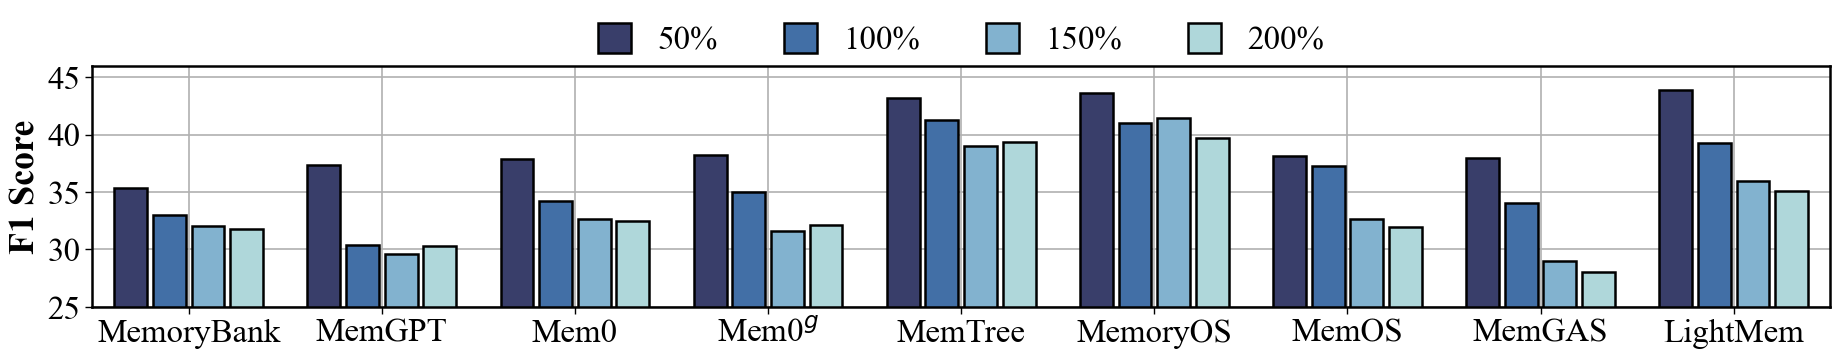

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

data_str = """memorybank,35.38,33.04,32.08,31.82
memgpt,37.32,30.36,29.61,30.34
mem0,37.92,34.20,32.62,32.46
mem0g,38.24,35.03,31.59,32.14
memtree,43.15,41.24,39.05,39.38
memoryos,43.62,41.02,41.46,39.73
memos,38.16,37.29,32.61,31.99
memgas,38.00,34.06,29.00,28.00
lightmem,43.85,39.31,36.00,35.1"""

names = ["MemoryBank", "MemGPT", "Mem0", r"Mem0$^g$", "MemTree", "MemoryOS", "MemOS", "MemGAS", "LightMem"]

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 2.2
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


df_wide = pd.read_csv(io.StringIO(data_str), header=None, 
                     names=['Methods', '50%', '100%', '150%', '200%'])


df_long = df_wide.melt(id_vars='Methods', var_name='Scale', value_name='F1 Score')


plt.figure(figsize=(19, 4))


colors = {'50%': '#313772', '100%': '#326db6', '150%': '#75b5dc', '200%': '#a8dde1'}
ax = sns.barplot(data=df_long, x='Methods', y='F1 Score', hue='Scale', palette=colors, edgecolor='black', linewidth=1.8, gap=0.15)

plt.tight_layout()

plt.ylim(25,46)
plt.xticks(ticks=range(len(names)), labels=names)
plt.yticks(ticks=range(25, 50, 5))
plt.xlabel('')
plt.ylabel('F1 Score', fontweight='bold')


for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False, handlelength=1, handleheight=1)

sns.set_context("paper", font_scale=2.7)
plt.grid(True, linewidth=1.2) 
ax.set_axisbelow(True)

plt.savefig('./figure/scale_overall.pdf', format='pdf', dpi=1000, bbox_inches='tight')
plt.show()


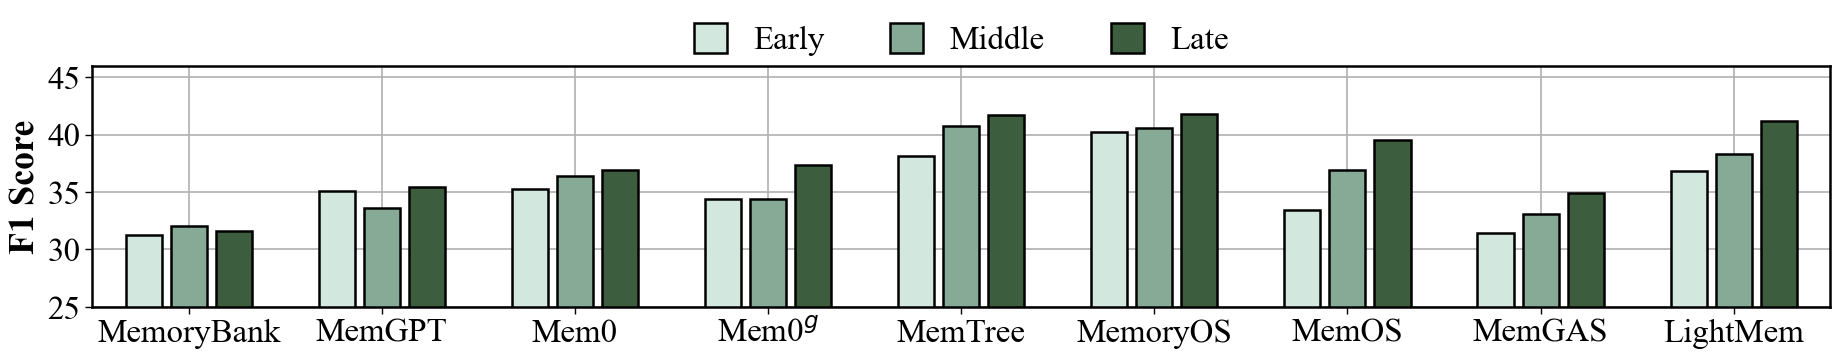

In [4]:
### POS

data_str = """memorybank,31.22,32.00,31.63
memgpt,35.13,33.57,35.42
mem0,35.28,36.40,36.94
mem0g,34.36,34.37,37.39
memtree,38.12,40.72,41.74
memoryos,40.20,40.58,41.83
memos,33.41,36.93,39.49
memgas,31.40,33.06,34.90
lightmem,36.80,38.31,41.20"""

names = ["MemoryBank", "MemGPT", "Mem0", r"Mem0$^g$", "MemTree", "MemoryOS", "MemOS", "MemGAS", "LightMem"]

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 2.2
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


df_wide = pd.read_csv(io.StringIO(data_str), header=None, 
                     names=['Methods', 'Early', 'Middle', 'Late'])


df_long = df_wide.melt(id_vars='Methods', var_name='Position', value_name='F1 Score')


plt.figure(figsize=(19, 4))


colors = {'Early': '#cfeadf', 'Middle': '#81b095', 'Late': '#376439'}
ax = sns.barplot(data=df_long, x='Methods', y='F1 Score', hue='Position', palette=colors, edgecolor='black', linewidth=1.8, gap=0.2,width=0.7)

plt.tight_layout()

plt.ylim(25,46)
plt.xticks(ticks=range(len(names)), labels=names)
plt.yticks(ticks=range(25, 50, 5))
plt.xlabel('')
plt.ylabel('F1 Score', fontweight='bold')


for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False, handlelength=1, handleheight=1)

sns.set_context("paper", font_scale=2.7)
plt.grid(True, linewidth=1.2) 
ax.set_axisbelow(True)

plt.savefig('./figure/position_overall.pdf', format='pdf', dpi=1000, bbox_inches='tight')
plt.show()


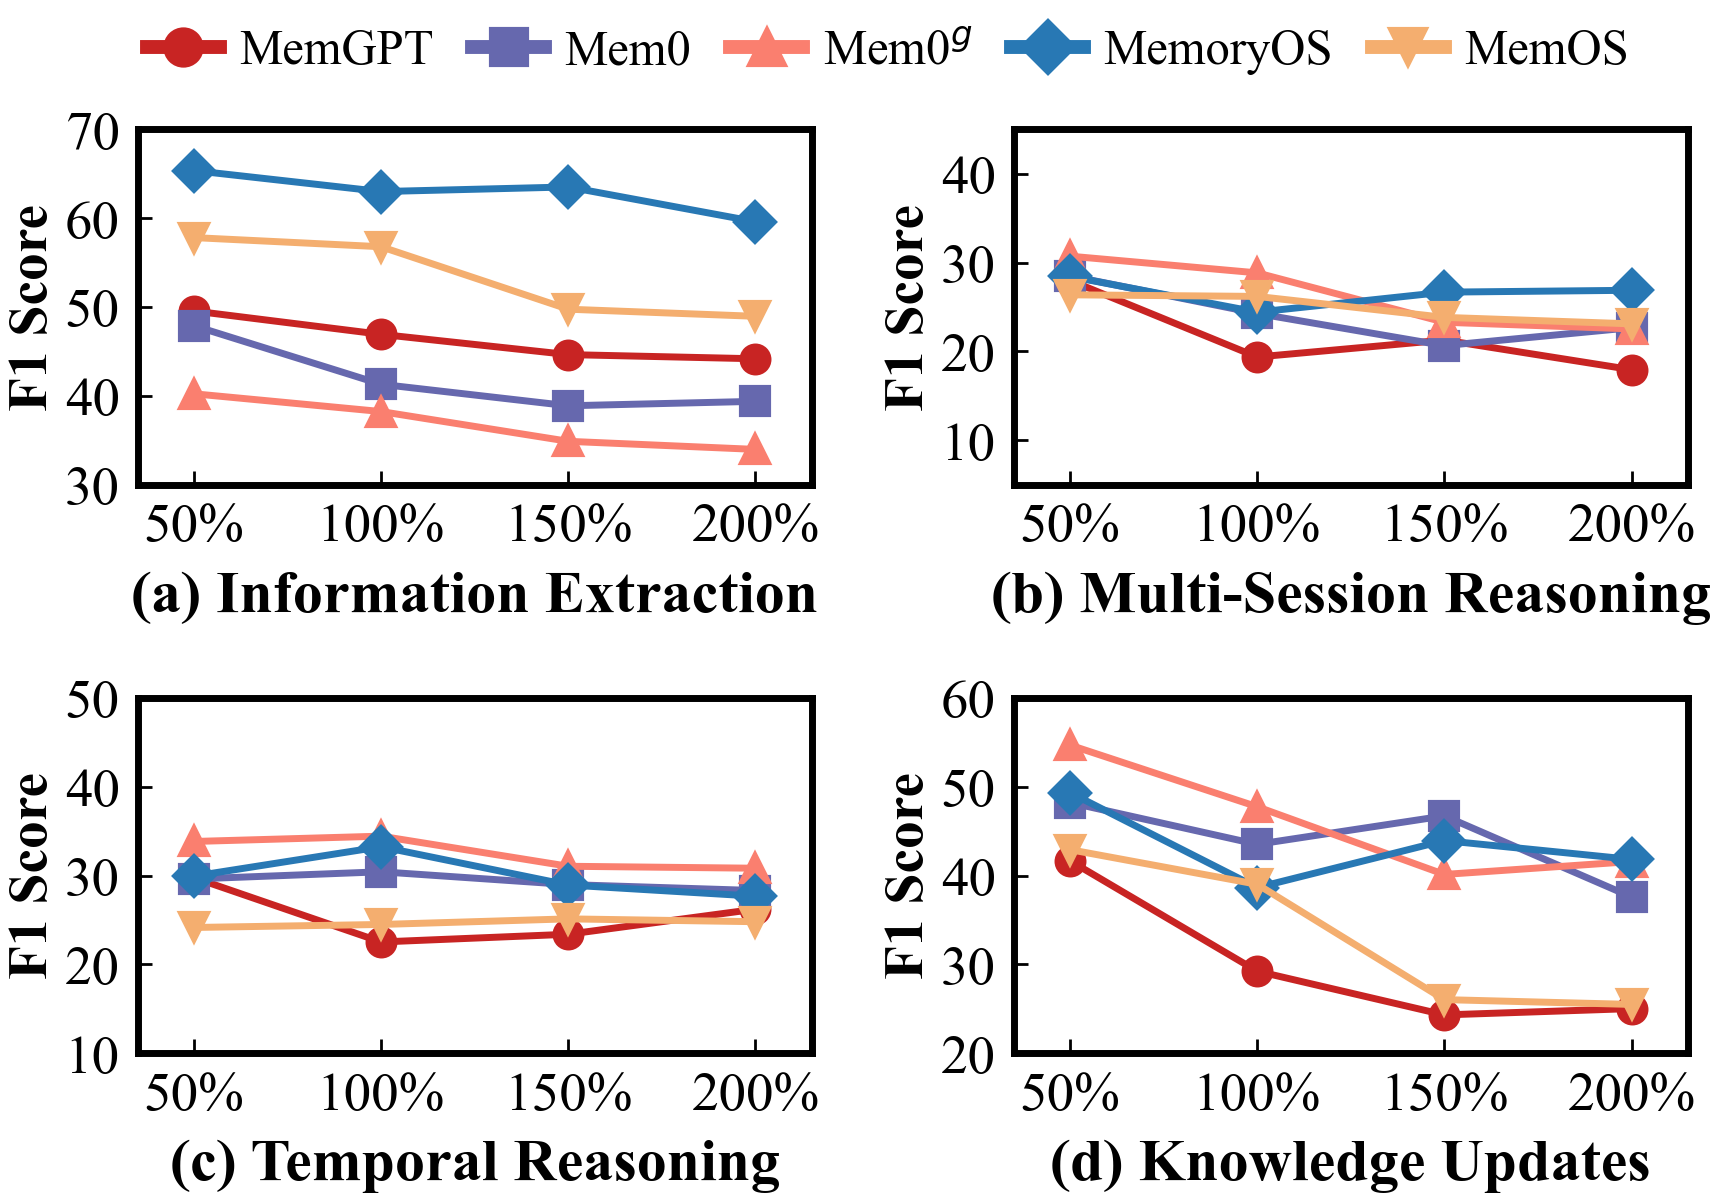

In [6]:


colors = {
    "MemGPT": "#c82423",
    "Mem0": "#6668ae",
    "Mem0$^g$": "#fa7f6f",
    "MemoryOS": "#2878b4",
    "MemOS": "#f4ae6f"
}

markers = {
    "MemGPT": "o",           
    "Mem0": "s",             
    "Mem0$^g$": "^",         
    "MemoryOS": "D",         
    "MemOS": "v"             
}
title_y = -0.38

plt.figure(figsize=(20,12))

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 2.2
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
names = ["MemGPT", "Mem0", r"Mem0$^g$", "MemoryOS", "MemOS"]

plt.subplot(2, 2, 1)
################################################## IE
data_str = """
MemGPT,49.55,46.92,44.64,44.17
Mem0,47.89,41.30,38.88,39.38
Mem0$^g$,40.23,38.23,34.88,33.97
MemoryOS,65.35,62.99,63.51,59.60
MemOS,57.81,56.78,49.75,48.95
"""


df_wide = pd.read_csv(io.StringIO(data_str), header=None, 
                     names=['Methods', '50%', '100%', '150%', '200%'])
df_long = df_wide.melt(id_vars='Methods', var_name='Scale', value_name='F1 Score')
for method in names:
    data = df_long[df_long['Methods'] == method]
    ax = sns.lineplot(data=data, x='Scale', y='F1 Score',
                 label=method,
                 color=colors[method],
                 marker=markers[method],
                 markersize=20,
                 linewidth=5,
                 legend=False,
                 markeredgecolor=colors[method],
                 markeredgewidth=3)
    
plt.xlabel('')
plt.ylabel('F1 Score', fontsize=40, fontweight='bold')
plt.title('(a) Information Extraction', fontweight='bold', y=title_y)
plt.ylim(30,70)
plt.yticks(ticks=range(30, 75, 10))

for spine in ax.spines.values():
    spine.set_linewidth(5)

plt.tick_params(direction='in', length=10, width=2, pad=13)
plt.margins(x=0.1)



plt.subplot(2, 2, 2)
################################################### MR
data_str = """
MemGPT,27.99,19.37,21.28,17.94
Mem0,28.50,24.27,20.65,22.67
Mem0$^g$,30.72,28.84,23.28,22.53
MemoryOS,28.44,24.42,26.67,26.88
MemOS,26.37,26.19,23.83,23.10
"""


df_wide = pd.read_csv(io.StringIO(data_str), header=None, 
                     names=['Methods', '50%', '100%', '150%', '200%'])
df_long = df_wide.melt(id_vars='Methods', var_name='Scale', value_name='F1 Score')
for method in names:
    data = df_long[df_long['Methods'] == method]
    ax = sns.lineplot(data=data, x='Scale', y='F1 Score',
                 label=method,
                 color=colors[method],
                 marker=markers[method],
                 markersize=20,
                 linewidth=5,
                 legend=False,
                 markeredgecolor=colors[method],
                 markeredgewidth=3)
    
plt.xlabel('')
plt.ylabel('F1 Score', fontsize=40, fontweight='bold')
plt.title('(b) Multi-Session Reasoning', fontweight='bold', y=title_y)
plt.ylim(5,45)
plt.yticks(ticks=range(10, 50, 10))

for spine in ax.spines.values():
    spine.set_linewidth(5)

plt.tick_params(direction='in', length=10, width=2, pad=13)
plt.margins(x=0.1)


plt.subplot(2, 2, 3)
################################################### TR
data_str = """
MemGPT,29.77,22.53,23.40,26.22
Mem0,29.62,30.43,28.99,28.32
Mem0$^g$,33.84,34.44,31.05,30.83
MemoryOS,29.94,33.25,28.94,27.68
MemOS,24.16,24.50,25.13,24.81
"""

df_wide = pd.read_csv(io.StringIO(data_str), header=None, 
                     names=['Methods', '50%', '100%', '150%', '200%'])
df_long = df_wide.melt(id_vars='Methods', var_name='Scale', value_name='F1 Score')
for method in names:
    data = df_long[df_long['Methods'] == method]
    ax = sns.lineplot(data=data, x='Scale', y='F1 Score',
                 label=method,
                 color=colors[method],
                 marker=markers[method],
                 markersize=20,
                 linewidth=5,
                 legend=False,
                 markeredgecolor=colors[method],
                 markeredgewidth=3)
    
plt.xlabel('')
plt.ylabel('F1 Score', fontsize=40, fontweight='bold')
plt.title('(c) Temporal Reasoning', fontweight='bold', y=title_y)
plt.ylim(10,50)
plt.yticks(ticks=range(10, 55, 10))

for spine in ax.spines.values():
    spine.set_linewidth(5)

plt.tick_params(direction='in', length=10, width=2, pad=13)
plt.margins(x=0.1)


plt.subplot(2, 2, 4)
################################################### KU
data_str = """
MemGPT,41.67,29.24,24.32,25.03
Mem0,48.22,43.52,46.72,37.59
Mem0$^g$,54.69,47.75,40.13,41.58
MemoryOS,49.34,38.65,43.94,41.82
MemOS,42.92,39.02,26.04,25.50
"""

df_wide = pd.read_csv(io.StringIO(data_str), header=None, 
                     names=['Methods', '50%', '100%', '150%', '200%'])
df_long = df_wide.melt(id_vars='Methods', var_name='Scale', value_name='F1 Score')
for method in names:
    data = df_long[df_long['Methods'] == method]
    ax = sns.lineplot(data=data, x='Scale', y='F1 Score',
                 label=method,
                 color=colors[method],
                 marker=markers[method],
                 markersize=20,
                 linewidth=5,
                 legend=False,
                 markeredgecolor=colors[method],
                 markeredgewidth=3)
    
plt.xlabel('')
plt.ylabel('F1 Score', fontsize=40, fontweight='bold')
plt.title('(d) Knowledge Updates', fontweight='bold', y=title_y)
plt.ylim(20,60)
plt.yticks(ticks=range(20, 65, 10))

for spine in ax.spines.values():
    spine.set_linewidth(5)

plt.tick_params(direction='in', length=10, width=2, pad=13)
plt.margins(x=0.1)


handles, labels = ax.get_legend_handles_labels()
fig = plt.gcf()
leg = fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 1),
           ncol=5,
           frameon=False,
           fontsize=38,
           markerscale=1.3,
           handlelength=1.5,
           handletextpad=0.4,
           columnspacing=0.8,
           prop={'family': 'Times New Roman', 'size': 35})
for handle in leg.legend_handles:
    handle.set_linewidth(10.0)


sns.set_context("paper", font_scale=4.5)
plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.savefig('./figure/scale_tasks.pdf', format='pdf', dpi=1000, bbox_inches='tight')
plt.show()

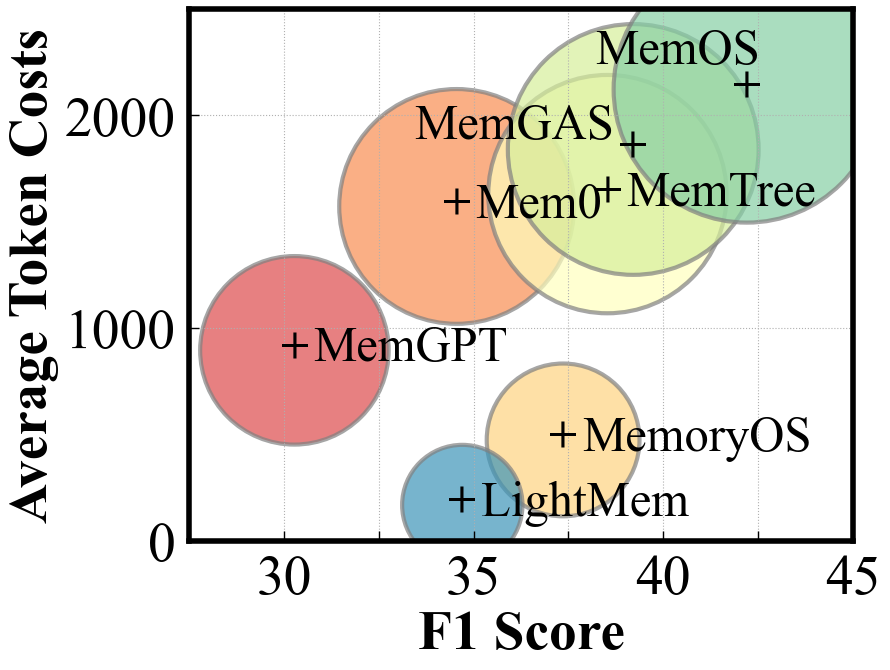

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(10,8))
# 数据
x = np.array([30.27, 34.55, 37.36, 38.53, 39.21, 42.21, 34.70])  # 10组数据 locomo
y = np.array([894.85646952, 1571.7155450264831, 473.40721184135145, 1629.72118443, 1839.6952567154028, 2122.6602785427767, 167.20010200612037])  # 10组数据

# [1917.06916055  114.895431    894.85646952 1571.71554503 1266.29349612
#   148.74809489 7120.48382025 1629.72118443  473.40721184 2122.66027854
#   432.25446709]

sizes = 5000+15*y  # 直径与y轴值线性

# 使用seaborn调色板生成10种颜色
colors = sns.color_palette("Spectral", n_colors=7)  # 9种颜色

names = ["MemGPT", "Mem0", "MemoryOS", "MemTree", "MemGAS", "MemOS", "LightMem"]  # 10个标签

# 创建散点图
plt.scatter(x, y, s=sizes, edgecolors='grey', linewidth=3, alpha=0.7, c=colors)

# 添加中心 +
for i in range(len(x)):
    if names[i] == "MemGAS":
        plt.text(x[i], y[i], '+', fontsize=35, ha='center', va='center', color='black', fontweight='bold')
        plt.text(x[i]-0.5, y[i], F"{names[i]}", 
                fontsize=35, ha='right', va='bottom')
    elif names[i] == "MemOS":
        plt.text(x[i], y[i], '+', fontsize=35, ha='center', va='center', color='black', fontweight='bold')
        plt.text(x[i]-4, y[i]+70, F"{names[i]}", 
                fontsize=35, ha='left', va='bottom')
    else:
        plt.text(x[i], y[i], '+', fontsize=35, ha='center', va='center', color='black', fontweight='bold')
        plt.text(x[i]+0.5, y[i]-100, F"{names[i]}", 
                fontsize=35, ha='left', va='bottom')  # 添加旁边的文本

plt.xlim(27.5,45)
plt.xticks([30, 32.5, 35, 37.5, 40, 42.5, 45], ["30", "", "35", "", "40", "", "45"], fontsize=40)

plt.yticks(fontsize=40)
plt.ylim(0, 2500)

# 设置边框宽度
for spine in plt.gca().spines.values():
    spine.set_linewidth(4)

plt.xlabel('F1 Score', fontsize=40, fontweight='bold')
plt.ylabel('Average Token Costs', fontsize=40, fontweight='bold')

plt.tick_params(direction='in', length=7, width=1, pad=10)

# 显示图形
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig("./figure/tradeoff.pdf",format='pdf',dpi=1000)
plt.show()



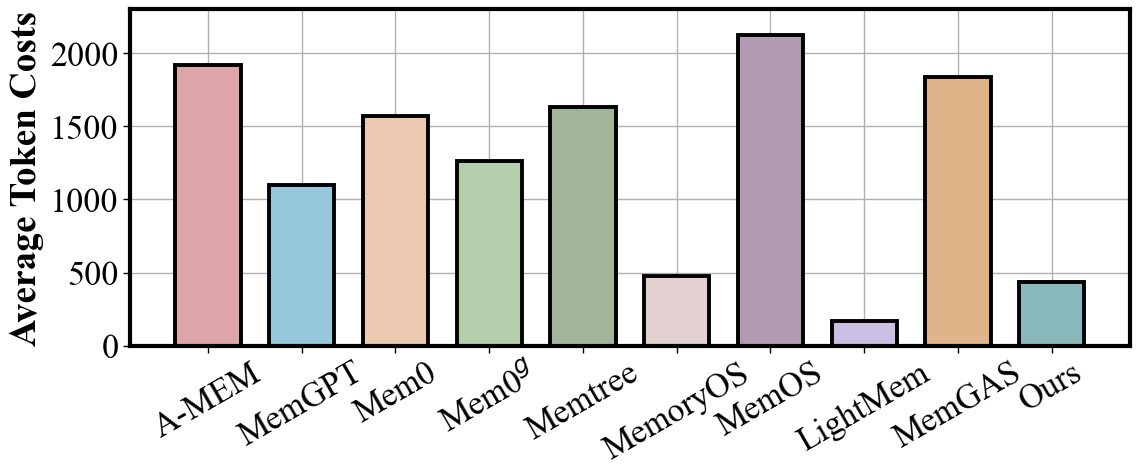

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


amem, memorybank, memgpt, mem0, mem0g, memochat, zep, memtree, memoryos, memos, lightmem, memgas, ours = [1917.0691605519164, 114.89543099766391, 1100.0, 1571.7155450264831, 1266.293496115243, 148.74809488965238, 7120.4838202538085, 1629.7211844299961, 473.40721184135145, 2122.6602785427767, 167.20010200612037, 1839.6952567154028, 432.25446708566216]
labels = ["A-MEM", "MemGPT", "Mem0", r"Mem0$^g$", "Memtree", "MemoryOS", "MemOS", "LightMem", "MemGAS", "Ours"]
colors = {
    "A-MEM": "#e89da0",
    "MemGPT": "#88cee6",
    "Mem0": "#f6c8a8",
    r"Mem0$^g$": "#b2d3a4",
    "Memtree": "#9fba95",
    "MemoryOS": "#e6cecf",
    "MemOS": "#b696b6",
    "Ours": "#80c1c4",
    "LightMem": "#c7b8ea",
    "MemGAS": "#f0b27a",
}
data = pd.DataFrame({
    'Methods': labels,
    'Average Token Costs': [amem, memgpt, mem0, mem0g, memtree, memoryos, memos, lightmem, memgas, ours]
})

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=data, x='Methods', y='Average Token Costs', hue='Methods', palette=colors, edgecolor='black', linewidth=2.8, gap=0.13)
plt.tight_layout()

plt.ylim(0, 2300)
plt.yticks(ticks=range(0, 2500, 500))
plt.xticks(rotation=30)
plt.ylabel('Average Token Costs', fontsize=27, fontweight='bold')
plt.xlabel("")

sns.set_context("paper", font_scale=2.8)
plt.grid(True, linewidth=1) 
ax.set_axisbelow(True)
ax.margins(x=0.05)

plt.savefig("./figure/sotacost.pdf", format='pdf', dpi=1000)
plt.show()

In [10]:
import numpy as np
amem = [1672.9689971139971, 1853.3781043956046, 1884.0627945420595, 1911.3872644022642, 1952.1661255411254, 1942.8813131313132, 1965.9773581973582, 1909.6610901014192, 1953.3790873015873, 1933.1186507936509, 1960.4626068960274, 1926.2216955266954, 1917.7984382284383, 1940.9654895104893, 1924.799513936356, 1948.1233333333334, 1933.9214499389498, 1921.728593073593, 1971.3121445221445]
memorybank = [100.2331465257123, 104.06406994408121, 112.64065450097758, 100.85472582972584, 121.1641185715393, 132.14509661613494, 130.6283993148982, 84.68513722176768, 119.73774187101742, 123.76611565890724, 116.13105303365367, 125.3777672544201, 113.53389131668594, 97.52308488612837, 108.35250586874426, 123.47837745098039, 118.26210413638046, 128.84123023715415, 121.5939687167053]
memgpt = [979.3863636363636, 988.8169642857142, 877.7777777777778, 774.2777777777778, 949.1291666666666, 822.8194444444443, 898.78125, 888.3977272727273, 921.0555555555555, 940.8392857142858, 987.025, 929.8298611111111, 876.1676136363636, 917.0288461538462, 803.8958333333333, 935.2083333333333, 849.8178571428572, 815.8169642857142, 846.2012987012987]
mem0 = [1552.0424800960513, 1508.1726625838105, 1350.1523343699332, 1830.2310134310137, 1521.6924111344142, 1524.9119858973977, 1730.4786606950474, 1530.891362016362, 1644.3102023031436, 1656.8625341515915, 1535.991898481881, 1430.6193797490591, 1554.020691237539, 1490.0971241636748, 1666.5127816676911, 1697.99298982751, 1581.2033128001171, 1551.560403726708, 1504.8511271702357]
# mem0 = [1052.4723204264872, 1117.3461216252883, 987.6605803600901, 977.380340955341, 999.8050084175084, 1013.77882996633, 1030.7364283864283, 1083.733292535924, 1150.5288461538462, 1155.4241622574957, 1100.9847512299266, 1122.8303771845437, 1110.5338038504706, 1107.900243384067, 1128.0719997595, 1163.702160493827, 1207.216115520282, 1178.7820947570947, 1137.4455798830797]
mem0g = [1287.365039281706, 1164.560236060236, 1281.3156577445793, 1234.6911730245063, 1296.9579966329968, 1257.0845258136926, 1241.7203509453511, 1250.144140889974, 1277.4889261972594, 1304.624007936508, 1277.13140194763, 1290.1364538239536, 1278.435167918501, 1289.489411650441, 1270.4376381821558, 1276.3069444444443, 1260.4030084113415, 1244.7999037999039, 1276.4844414844415]
memochat = [112.60073006020374, 144.83557942460106, 151.27606002962193, 128.8964872028556, 162.05495630861043, 153.634069539347, 157.6896417738994, 154.31964893899675, 135.21256695660722, 163.65873857014074, 140.19531529358153, 149.62856785202047, 157.83572999981465, 149.79329921582158, 152.39962511344865, 153.24172832817337, 142.55334308354045, 151.20994894598155, 165.17776626612945]
zep = [5464.1068660825895, 6557.800903080764, 7161.685979204398, 6823.720984273035, 7281.665940113594, 7124.615571897909, 7442.225036292902, 7293.952241124524, 7202.684474192016, 7524.191745548795, 7460.986900942195, 7120.701961405963, 7320.439391814584, 7226.546057744354, 7481.747210412567, 7234.36644246646, 6927.635285908378, 7316.792783267457, 7323.326809049859]
memtree = [937.1920286009572, 1211.2025409319108, 1400.5885272818803, 1548.4620924105134, 1537.5804273883466, 1608.0331437727032, 1870.0328661379083, 1652.030436326865, 1686.9266230936817, 1865.1719607383184, 1825.0640881232873, 1847.0818811861523, 1659.5264824253952, 1750.577867958778, 1752.4415182340879, 1597.1299590888989, 1717.1017146463576, 1703.578827875023, 1794.979517948864]
memoryos = [374.3729509379509, 451.27567307692306, 436.1736858076564, 467.64108696858705, 463.2700108225108, 512.8369949494949, 449.10732905982906, 493.59524489399485, 545.9335943223443, 489.97559523809525, 512.2718783701678, 430.05382575757574, 489.4013480963481, 498.77483185931703, 459.54848389914184, 486.1281944444445, 483.42211691086686, 505.7323863636364, 445.2217932067932]
memos = [2116.7981311386575, 2120.1307808499637, 2121.722668133359, 2181.7873751511647, 2081.480601842318, 2188.896953161255, 2105.931803211222, 2123.203906641733, 2016.7659622913493, 2112.0845695289613, 2155.6954262662002, 2091.6076390210465, 2114.232059690229, 2141.0268663987335, 2150.1953449852517, 2090.3640825593397, 2203.149950213371, 2039.7531159420291, 2175.7180552865716]
ours = [65.0427126938969, 269.8615062704545, 357.2116164232874, 343.4109121521753, 403.1730911139159, 456.7248368765102, 441.39605774579195, 486.2806212402952, 519.5958904942094, 408.0784888438134, 468.6829504241888, 564.5066563716151, 343.27369545642995, 474.3483369023937, 499.0368792198513, 536.2744259545924, 519.2174066012224, 497.3449752964426, 559.3738145464936]
all = np.array([amem, memorybank, memgpt, mem0, mem0g, memochat, zep, memtree, memoryos, memos, ours])
allmean = all.mean(axis=1)
print(allmean)   

[1917.06916055  114.895431    894.85646952 1571.71554503 1266.29349612
  148.74809489 7120.48382025 1629.72118443  473.40721184 2122.66027854
  432.25446709]


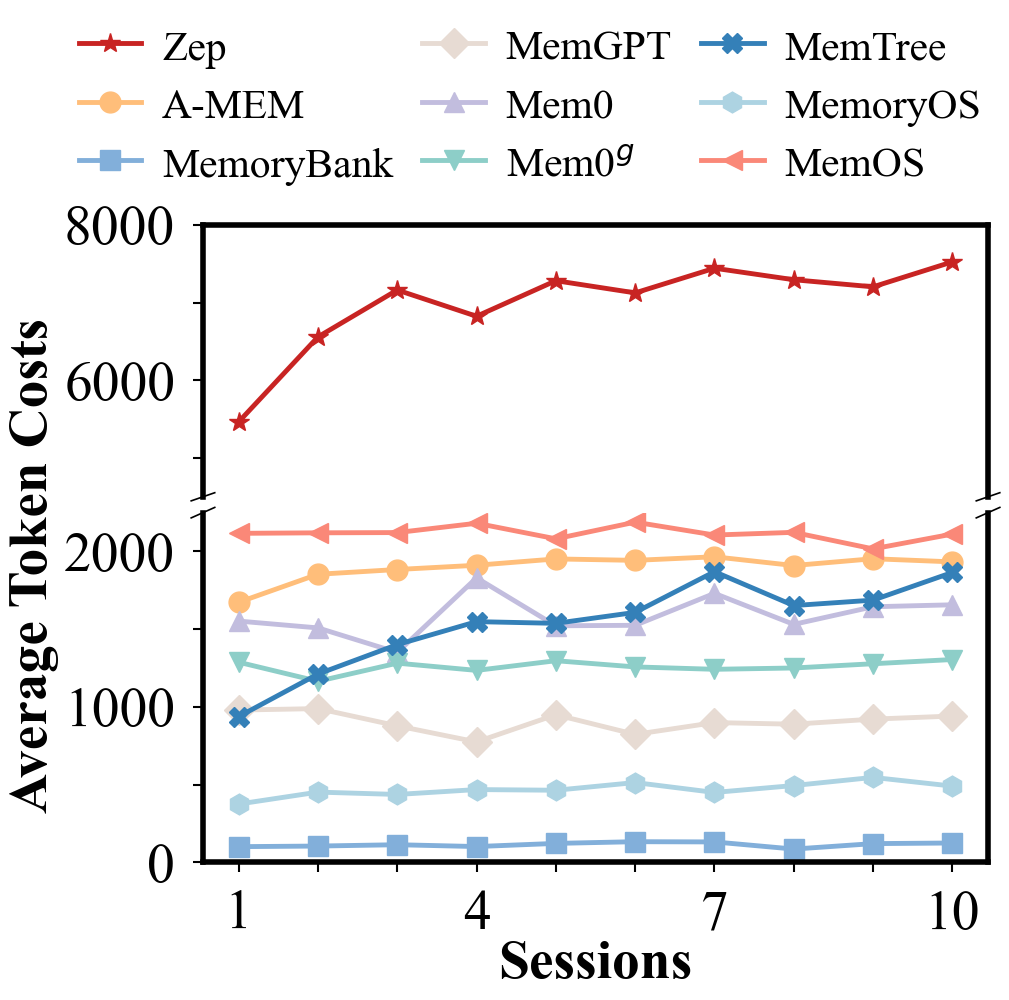

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

all = np.array([amem, memorybank, memgpt, mem0, mem0g, zep, memtree, memoryos, memos])
all = np.array([i[0:10] for i in all])
names = ["A-MEM", "MemoryBank", "MemGPT", "Mem0", r"Mem0$^g$", "Zep", "MemTree", "MemoryOS", "MemOS"]
df = pd.DataFrame(all.T, columns=names)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# 2. 设置比例：通过 height_ratios 调整上下子图的高度比
# 这里的 [1, 2] 表示上半部分占 1 份，下半部分占 2 份
fig, (ax_top, ax_bot) = plt.subplots(2, 1, sharex=True, 
                                     gridspec_kw={'height_ratios': [7, 9]}, figsize=(10, 8))

# 调整子图间的垂直间距为 0.05 (稍微留一点缝隙放截断符号)


# 3. 分别绘图
colors = {
    "A-MEM": "#ffbe7a",
    "MemoryBank": "#82afda",
    "MemGPT": "#e7dbd3",
    "Mem0": "#c2bdde",
    r"Mem0$^g$": "#8dcec8",
    "Zep": "#c82423",
    "MemoryOS": "#add3e2",
    "MemOS": "#fa8878",
    "MemTree": "#3480b8",
}
markers = {
    "A-MEM": "o",
    "MemoryBank": "s",
    "MemGPT": "D",
    "Mem0": "^",
    r"Mem0$^g$": "v",
    "Zep": "*",
    "MemoryOS": "h",
    "MemOS": "<",
    "MemTree": "X",
}

for method in names:
    if method == "Zep":
        data = df[method]
        ax_top.plot([1,2,3,4,5,6,7,8,9,10], data, color=colors[method], 
                    marker=markers[method], ms=15, linewidth=3.5, label=method)
    else:
        data = df[method]
        ax_bot.plot([1,2,3,4,5,6,7,8,9,10], data, color=colors[method],
                marker=markers[method], ms=15, linewidth=3.5, label=method)

# 4. 设置 Y 轴范围
ax_top.set_ylim(4500, 8000)  # 上半部分显示高位数据区间
ax_top.set_yticks([5000, 6000, 7000, 8000], labels=['', 6000, '', 8000], fontsize=40)
ax_bot.set_ylim(0, 2250)    # 下半部分显示低位数据区间
ax_bot.set_yticks([0, 500, 1000, 1500, 2000], labels=[0, '', 1000, '', 2000], fontsize=40)
ax_bot.set_xticks([1,2,3,4,5,6,7,8,9,10], labels=[1,'','',4,'','',7,'','',10], fontsize=40)

# 5. 隐藏重叠的边框
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)

# 隐藏上半部分的底部刻度线（因为 sharex=True，刻度默认在最下面）
ax_top.tick_params(labelbottom=False, bottom=False)

# 6. 绘制截断符号 (双斜杠)
# d 决定斜杠的大小，kwargs 控制其在坐标系外的延伸
d = .015 
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)        # 左上斜杠
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # 右上斜杠

d = .015
kwargs.update(transform=ax_bot.transAxes)        # 切换到下半部分坐标系
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # 左下斜杠
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) # 右下斜杠

for spine in ax_top.spines.values():
    spine.set_linewidth(4)
for spine in ax_bot.spines.values():
    spine.set_linewidth(4)
plt.tight_layout(h_pad=0.2)
ax_top.tick_params(length=7, width=1.5, pad=13)
ax_bot.tick_params(length=7, width=1.5, pad=13)
fig.supylabel('Average Token Costs', fontsize=40, fontweight='bold', x=-0.03)
plt.xlabel('Sessions', fontsize=40, fontweight='bold', labelpad=0)

# 7. 设置统一图例
# 使用 fig.legend 可以在整个画布级别添加图例，避免上下子图各自重复
fig.legend(loc='upper center', bbox_to_anchor=(0.49, 1.22), ncol=3, frameon=False, handlelength=1.5, handleheight=1, fontsize = 30, columnspacing=0.7, handletextpad=0.5, labelspacing=0.4, markerscale=1)
sns.set_context("paper", font_scale=3.2)

plt.savefig("./figure/token.pdf", format='pdf', dpi=1000, bbox_inches='tight')
plt.show()
